In [14]:
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
# Requires: python compute_metrics.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results/metrics.csv")
print(f"{len(df)} samples")
print(df[["snr_raw", "snr_pp", "snr_denoised"]].describe().round(2))

72 samples
       snr_raw  snr_pp  snr_denoised
count    72.00   72.00         72.00
mean      0.03    9.18         11.89
std       0.13    3.73          6.58
min      -0.37   -0.30         -2.07
25%      -0.02    7.30          7.35
50%       0.02    9.93         12.23
75%       0.08   11.56         15.75
max       0.38   16.61         26.92


/tmp/ipykernel_3141420/3780819883.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, medianprops=dict(color="black", linewidth=2))


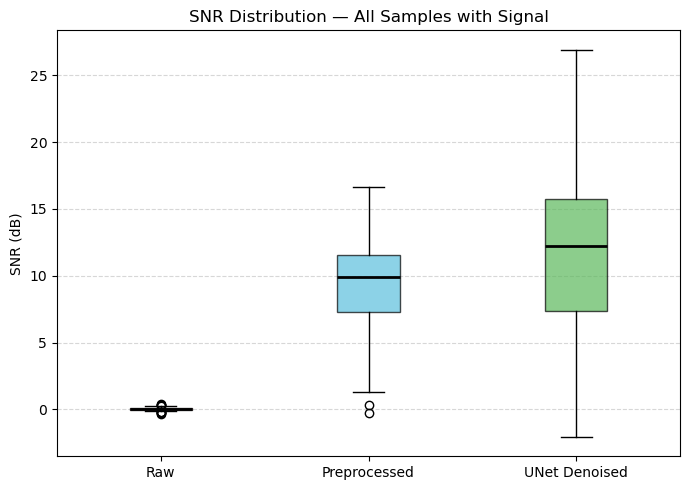

Medians:
              Raw: 0.02 dB
     Preprocessed: 9.93 dB
    UNet Denoised: 12.23 dB


In [17]:
# Boxplot: SNR distribution per method
methods = ["snr_raw", "snr_pp", "snr_denoised"]
labels  = ["Raw", "Preprocessed", "UNet Denoised"]
data    = [df[m].dropna().values for m in methods]

fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot(data, labels=labels, patch_artist=True, medianprops=dict(color="black", linewidth=2))
colors = ["#d9534f", "#5bc0de", "#5cb85c"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("SNR (dB)")
ax.set_title("SNR Distribution — All Samples with Signal")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("Medians:")
for m, lbl in zip(methods, labels):
    print(f"  {lbl:>15s}: {df[m].median():.2f} dB")

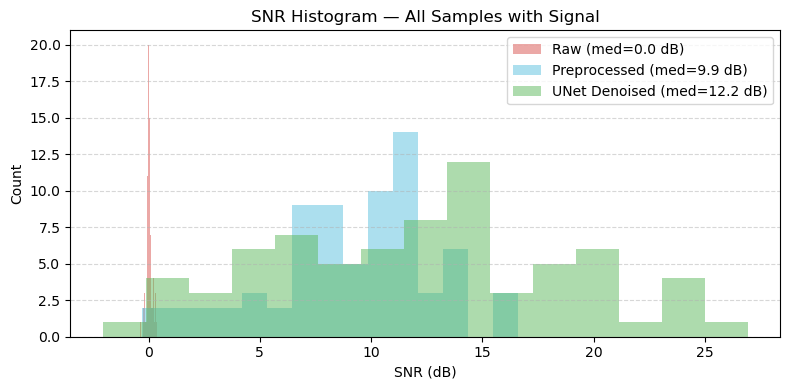

In [18]:
# Overlapping histograms
colors = ["#d9534f", "#5bc0de", "#5cb85c"]
fig, ax = plt.subplots(figsize=(8, 4))
for m, lbl, color in zip(methods, labels, colors):
    vals = df[m].dropna().values
    ax.hist(vals, bins=15, alpha=0.5, label=f"{lbl} (med={np.median(vals):.1f} dB)", color=color)

ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Count")
ax.set_title("SNR Histogram — All Samples with Signal")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

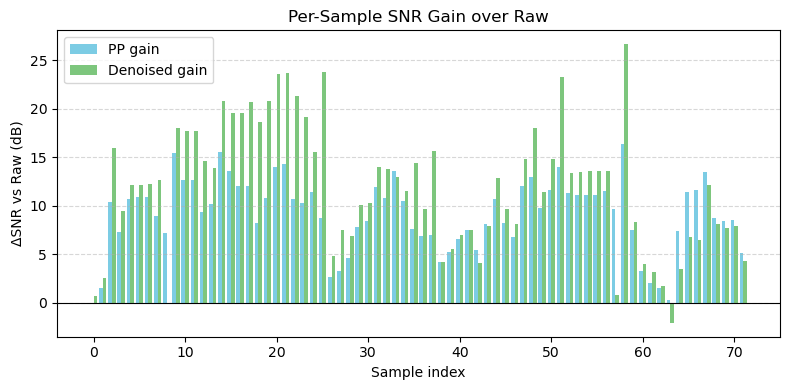

Median ΔSNR (pp - raw):       9.95 dB
Median ΔSNR (denoised - raw): 12.19 dB


In [19]:
# Per-sample paired comparison: denoised gain over raw
df["gain_pp"]       = df["snr_pp"]       - df["snr_raw"]
df["gain_denoised"] = df["snr_denoised"] - df["snr_raw"]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(df))
ax.bar(x - 0.2, df["gain_pp"],       width=0.4, label="PP gain",       color="#5bc0de", alpha=0.8)
ax.bar(x + 0.2, df["gain_denoised"], width=0.4, label="Denoised gain", color="#5cb85c", alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Sample index")
ax.set_ylabel("ΔSNR vs Raw (dB)")
ax.set_title("Per-Sample SNR Gain over Raw")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Median ΔSNR (pp - raw):       {df['gain_pp'].median():.2f} dB")
print(f"Median ΔSNR (denoised - raw): {df['gain_denoised'].median():.2f} dB")

In [20]:
from Utilities import plot_das_data, compute_snr
from preprocessing import make_preprocess
import yaml, json
from config import DAS_FILE
from DAS import DAS

den_cfg   = yaml.safe_load(open("configs/denoising.yaml"))
dp_cfg    = yaml.safe_load(open("configs/data_prep.yaml"))
_meta     = DAS(DAS_FILE).meta
dx        = den_cfg.get("dx") or _meta["dx"]
dt        = den_cfg.get("dt") or _meta["dt"]
fs_das    = den_cfg["fs"]
fps_video = dp_cfg["fps_video"]

steps = [(s["name"], {k: v for k, v in s.items() if k != "name"}) for s in den_cfg["steps"]]
pp = make_preprocess(steps=steps, dx=dx, dt=dt)

# Also load full labels.csv to get data_path and signal_rects (metrics.csv only has SNR values)
labels_df = pd.read_csv("data/labels.csv")
labels_df = labels_df[labels_df["count"] > 0].reset_index(drop=True)

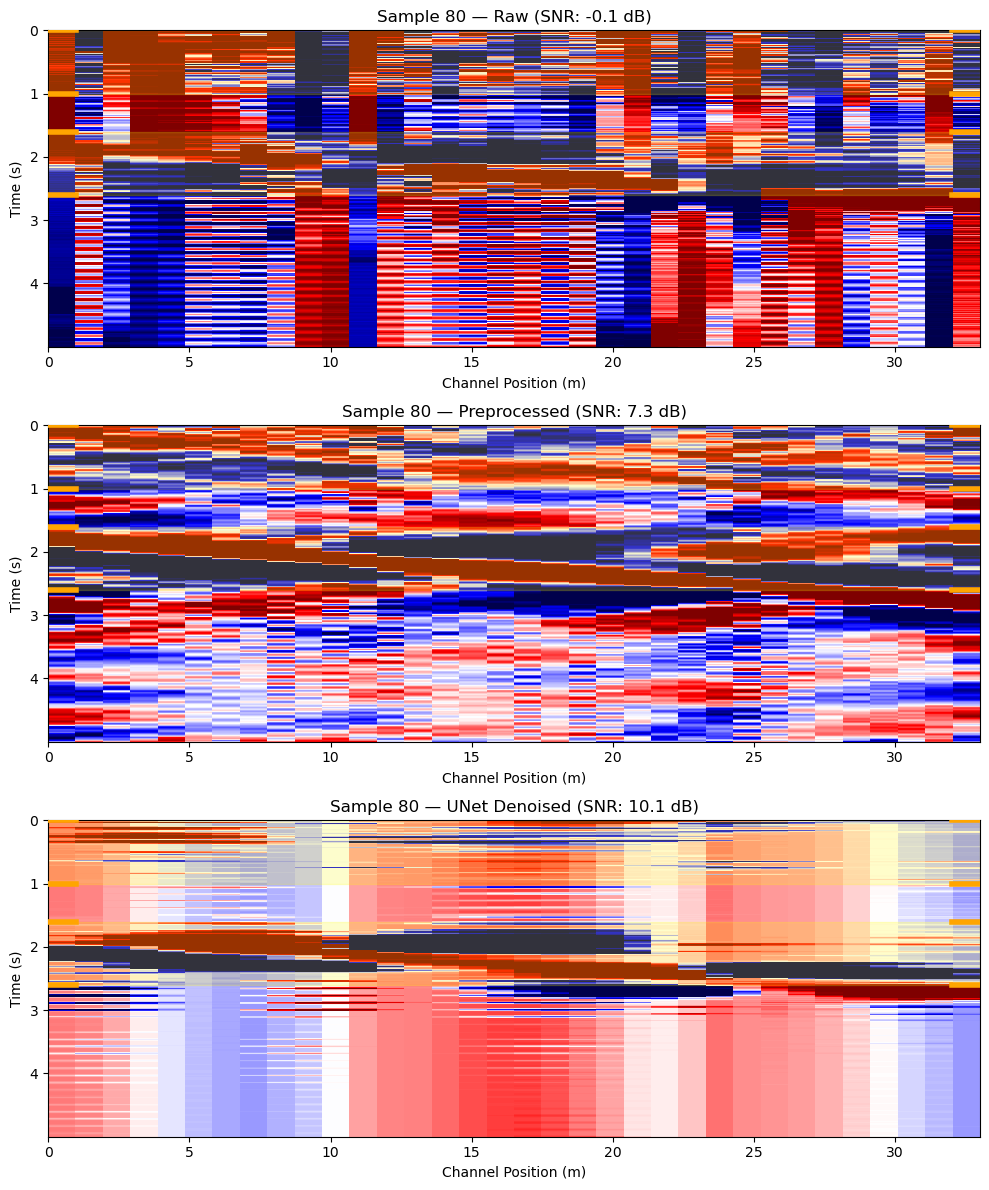

SNR  raw=-0.07 dB | pp=7.34 dB | denoised=10.15 dB


In [24]:
SAMPLE_IDX = 65  # index into the count>0 sample list; change to inspect different samples
row    = labels_df.iloc[SAMPLE_IDX]
sid    = row["sample_id"]
rects  = json.loads(row["signal_rects"])
win_start_frame = row["start_frame"]

raw      = np.load(row["data_path"]).astype(np.float32)
clean    = pp(raw, fs_das).astype(np.float32)
denoised = np.load(f"data/denoised/denoised_sample_{int(sid):06d}.npy").astype(np.float32)

snr_raw   = compute_snr(raw,      rects, win_start_frame, fps_video, fs_das)
snr_clean = compute_snr(clean,    rects, win_start_frame, fps_video, fs_das)
snr_pred  = compute_snr(denoised, rects, win_start_frame, fps_video, fs_das)

channels = np.arange(raw.shape[0])
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
plot_das_data(data=raw,      channels=channels, dx=dx, dt=dt,
              title=f"Sample {sid} — Raw (SNR: {snr_raw:.1f} dB)",
              ax=axes[0], fig=fig, show=False)
plot_das_data(data=clean,    channels=channels, dx=dx, dt=dt,
              title=f"Sample {sid} — Preprocessed (SNR: {snr_clean:.1f} dB)",
              ax=axes[1], fig=fig, show=False)
plot_das_data(data=denoised, channels=channels, dx=dx, dt=dt,
              title=f"Sample {sid} — UNet Denoised (SNR: {snr_pred:.1f} dB)",
              ax=axes[2], fig=fig, show=False)

for ax in axes:
    for r_s, r_e in rects:
        t_s = (r_s - win_start_frame) / fps_video
        t_e = (r_e - win_start_frame) / fps_video
        ax.axhspan(t_s, t_e, alpha=0.2, color="yellow", zorder=2)
        for t in (t_s, t_e):
            ax.axhline(t, xmin=0, xmax=0.03, color="orange", linewidth=4, zorder=3)
            ax.axhline(t, xmin=0.97, xmax=1.0, color="orange", linewidth=4, zorder=3)

plt.tight_layout()
plt.show()
print(f"SNR  raw={snr_raw:.2f} dB | pp={snr_clean:.2f} dB | denoised={snr_pred:.2f} dB")